# Fase 2 — Otimização via Algoritmo Genético + Interpretação com LLM
## Câncer de mama: Regressão Linear, Regressão Logística e Random Forest

Este notebook usa as funções de `src/ga_utils.py` (Algoritmo Genético) e `src/llm_utils.py` (integração com o Claude) para:

1. Otimizar os hiperparâmetros dos 3 modelos já treinados em `01_analise_e_modelagem.ipynb`.
2. Rodar 3 experimentos com configurações diferentes do GA (um por algoritmo).
3. Comparar cada modelo original com sua versão otimizada, no mesmo holdout de teste.
4. Depois do treino, ler as **feature importances** do melhor modelo e exportar as 10 medidas que mais pesaram (`experiments/results/feature_importances.json`) — a API e o Angular consomem esse arquivo no exame simplificado.
5. Pedir ao Claude um **laudo de um paciente** (igual à API/front) e um **relatório dos experimentos** do GA. Os prompts ficam em `src/llm_utils.py`.

O loop de gerações do GA aparece direto nas células abaixo (um bloco por algoritmo) — dá pra acompanhar geração por geração o que está acontecendo, sem precisar pular pra outro arquivo.

## O que é um Algoritmo Genético (GA)?

*Por que usar uma "busca evolutiva" em vez de testar hiperparâmetros manualmente?*

Um Algoritmo Genético é uma técnica de otimização inspirada na seleção natural. Em vez de testar hiperparâmetros um por um (grid search) ou aleatoriamente (random search), ele mantém uma **população** de soluções candidatas e as faz "evoluir":

- **Indivíduo**: um dict com uma configuração completa de hiperparâmetros de um modelo.
- **Gene**: cada hiperparâmetro individual (uma chave do dict).
- **Fitness**: quão boa é aquela configuração — `0.5·recall + 0.3·F1 + 0.2·accuracy`, medidos por validação cruzada (5-fold).
- **Seleção**: as configurações com melhor fitness têm mais chance de "reproduzir".
- **Crossover**: duas configurações "pais" combinam seus genes para gerar "filhos".
- **Mutação**: pequenas alterações aleatórias, para explorar configurações novas.
- **Elitismo**: as melhores configurações da geração atual sempre sobrevivem para a próxima.

*Por que recall pesa mais na fitness?* Em diagnóstico de câncer, classificar um tumor **maligno como benigno** (falso negativo) é o erro mais grave clinicamente.

*Por que seleção por torneio?* É simples de implementar e funciona bem mesmo quando os fitness estão próximos entre si — sorteia `k` indivíduos, o melhor deles vira pai.

*Por que crossover uniforme?* Os hiperparâmetros não têm uma ordem natural entre si, então decidir gene a gene (independentemente) de qual pai herdar faz mais sentido do que cortar o dict num ponto fixo.

In [2]:
import sys
import json
import random
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ga_utils
import llm_utils

X_train, X_test, y_train, y_test, feature_names, scaler = ga_utils.carregar_dados()
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

RESULTADOS_DIR = Path("..") / "experiments" / "results"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

Treino: (455, 30) | Teste: (114, 30)


## Baseline (Fase 1) — modelos originais

Métricas obtidas em `01_analise_e_modelagem.ipynb`, no mesmo holdout de teste (20%, `random_state=42`):

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Linear (limiar 0,5) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| Regressão Logística | 0.9649 | 0.9750 | 0.9286 | 0.9512 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

Vamos rodar o GA para tentar melhorar cada um desses três — um experimento por algoritmo, cada um com uma configuração diferente do GA.

## Experimento 1 — GA na Regressão Linear

*Por que o limiar (threshold) entra como gene?* `LinearRegression` não tem hiperparâmetro de regularização como Ridge/Lasso — a única forma de melhorar a classificação sem trocar de modelo é ajustar o limiar que converte a predição contínua em classe 0/1 (hoje fixo em 0,5 no notebook 01). Junto com `fit_intercept` e `positive`, esse é o espaço de busca do GA aqui.

**Configuração deste experimento**: população pequena (10), mutação baixa (10%), 10 gerações.

Geração 0: melhor=0.9668  média=0.7862
Geração 1: melhor=0.9668  média=0.9559
Geração 2: melhor=0.9668  média=0.9388
Geração 3: melhor=0.9668  média=0.9411
Geração 4: melhor=0.9668  média=0.9380
Geração 5: melhor=0.9668  média=0.9368
Geração 6: melhor=0.9668  média=0.9664
Geração 7: melhor=0.9668  média=0.9624
Geração 8: melhor=0.9668  média=0.9395
Geração 9: melhor=0.9668  média=0.9631

Melhores hiperparâmetros encontrados: {'fit_intercept': True, 'positive': True, 'threshold': 0.33747809594463696}


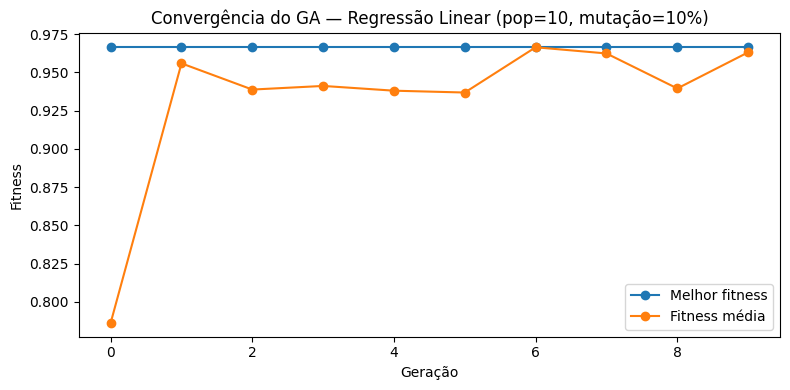

In [3]:
random.seed(42)

POP_1, GERACOES_1, MUTACAO_1 = 10, 10, 0.1

populacao = [ga_utils.criar_individuo_linear() for _ in range(POP_1)]
historico_linear = []

for geracao in range(GERACOES_1):
    fitnesses = [ga_utils.fitness_linear(ind, X_train, y_train) for ind in populacao]
    historico_linear.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]  # elitismo
    while len(nova_populacao) < POP_1:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_linear(filho1, MUTACAO_1))
        if len(nova_populacao) < POP_1:
            nova_populacao.append(ga_utils.mutar_linear(filho2, MUTACAO_1))
    populacao = nova_populacao

melhor_linear = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_linear)

pd.DataFrame(historico_linear).to_csv(RESULTADOS_DIR / "fitness_history_regressao_linear.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_linear.json", "w") as f:
    json.dump({"algoritmo": "regressao_linear", "melhor_individuo": melhor_linear}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_linear], [h["melhor"] for h in historico_linear], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_linear], [h["media"] for h in historico_linear], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Regressão Linear (pop=10, mutação=10%)")
plt.legend(); plt.tight_layout(); plt.show()

In [4]:
modelo_linear_original = ga_utils.construir_linear(ga_utils.LINEAR_BASELINE)
modelo_linear_original.fit(X_train, y_train)
y_pred_original = ga_utils.prever_linear(modelo_linear_original, X_test, ga_utils.LINEAR_BASELINE)
metricas_linear_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_linear_otimizado = ga_utils.construir_linear(melhor_linear)
modelo_linear_otimizado.fit(X_train, y_train)
y_pred_otimizado = ga_utils.prever_linear(modelo_linear_otimizado, X_test, melhor_linear)
metricas_linear_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_linear_original, metricas_linear_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.964912,1.000000,0.904762,0.950000
Otimizado (GA),0.964912,0.931818,0.976190,0.953488


## Experimento 2 — GA na Regressão Logística

*O que o GA está ajustando aqui?* `C` (inverso da força de regularização), `penalty` (L1 tende a zerar coeficientes menos relevantes, L2 só os encolhe) e `class_weight` (se as classes têm peso igual ou compensam o leve desbalanceamento do dataset).

**Configuração deste experimento**: população maior (20), mutação alta (30%), 10 gerações.

c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

Geração 0: melhor=0.9604  média=0.8690


c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

Geração 1: melhor=0.9635  média=0.9550


c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' wa

...

Geração 7: melhor=0.9648  média=0.9564


c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' wa

Geração 8: melhor=0.9648  média=0.9580


c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' wa

Geração 9: melhor=0.9648  média=0.9610

Melhores hiperparâmetros encontrados: {'C': 0.025631932887737845, 'penalty': 'l2', 'class_weight': 'balanced'}


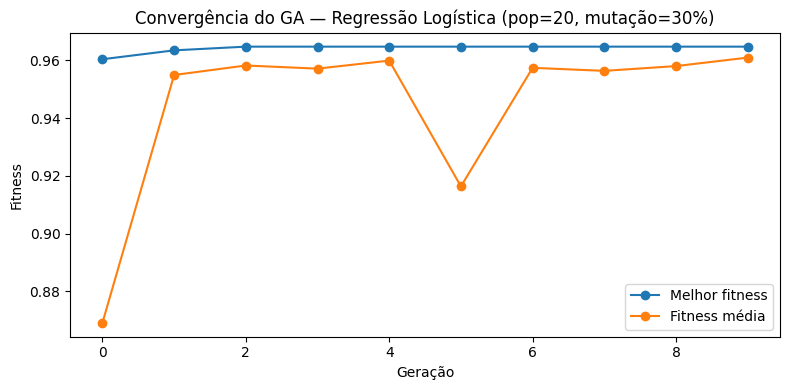

In [5]:
random.seed(42)

POP_2, GERACOES_2, MUTACAO_2 = 20, 10, 0.3

populacao = [ga_utils.criar_individuo_log() for _ in range(POP_2)]
historico_log = []

for geracao in range(GERACOES_2):
    fitnesses = [ga_utils.fitness_log(ind, X_train, y_train) for ind in populacao]
    historico_log.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]
    while len(nova_populacao) < POP_2:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_log(filho1, MUTACAO_2))
        if len(nova_populacao) < POP_2:
            nova_populacao.append(ga_utils.mutar_log(filho2, MUTACAO_2))
    populacao = nova_populacao

melhor_log = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_log)

pd.DataFrame(historico_log).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", "melhor_individuo": melhor_log}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_log], [h["melhor"] for h in historico_log], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_log], [h["media"] for h in historico_log], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Regressão Logística (pop=20, mutação=30%)")
plt.legend(); plt.tight_layout(); plt.show()

In [6]:
modelo_log_original = ga_utils.construir_log(ga_utils.LOG_BASELINE)
modelo_log_original.fit(X_train, y_train)
y_pred_original = modelo_log_original.predict(X_test)
metricas_log_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_log_otimizado = ga_utils.construir_log(melhor_log)
modelo_log_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_log_otimizado.predict(X_test)
metricas_log_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_log_original, metricas_log_otimizado], index=["Original", "Otimizado (GA)"])

c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,accuracy,precision,recall,f1
Original,0.973684,0.97561,0.952381,0.963855
Otimizado (GA),0.991228,1.00000,0.976190,0.987952


## Experimento 3 — GA no Random Forest

*O que o GA está ajustando aqui?* `n_estimators` (nº de árvores), `max_depth` (profundidade máxima), `min_samples_split`/`min_samples_leaf` (o quão fácil é criar uma nova divisão), `max_features` (quantas features considerar em cada split) e `criterion` (gini vs. entropia).

**Configuração deste experimento**: população média (15), mutação média (20%), mais gerações (20) — o Random Forest já é o melhor baseline, então damos mais tempo de busca pra ele.

Geração 0: melhor=0.9441  média=0.9353
Geração 1: melhor=0.9523  média=0.9387
Geração 2: melhor=0.9523  média=0.9412
Geração 3: melhor=0.9566  média=0.9469
Geração 4: melhor=0.9566  média=0.9458
Geração 5: melhor=0.9566  média=0.9511
Geração 6: melhor=0.9591  média=0.9492
Geração 7: melhor=0.9591  média=0.9518
Geração 8: melhor=0.9592  média=0.9477
Geração 9: melhor=0.9592  média=0.9474
Geração 10: melhor=0.9592  média=0.9478
Geração 11: melhor=0.9592  média=0.9481
Geração 12: melhor=0.9635  média=0.9541
Geração 13: melhor=0.9635  média=0.9516
Geração 14: melhor=0.9635  média=0.9516
Geração 15: melhor=0.9635  média=0.9488
Geração 16: melhor=0.9635  média=0.9541
Geração 17: melhor=0.9635  média=0.9546
Geração 18: melhor=0.9635  média=0.9464
Geração 19: melhor=0.9635  média=0.9524

Melhores hiperparâmetros encontrados: {'n_estimators': 147, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}


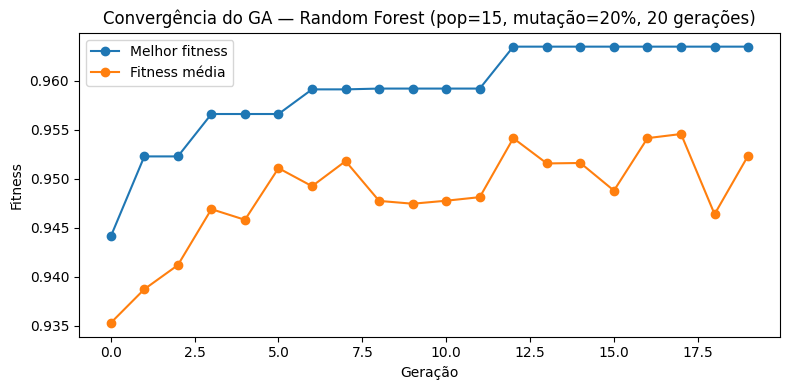

In [7]:
random.seed(42)

POP_3, GERACOES_3, MUTACAO_3 = 15, 20, 0.2

populacao = [ga_utils.criar_individuo_rf() for _ in range(POP_3)]
historico_rf = []

for geracao in range(GERACOES_3):
    fitnesses = [ga_utils.fitness_rf(ind, X_train, y_train) for ind in populacao]
    historico_rf.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
    print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

    ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
    nova_populacao = [dict(populacao[i]) for i in ranking[:2]]
    while len(nova_populacao) < POP_3:
        pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
        pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
        filho1, filho2 = ga_utils.crossover(pai1, pai2)
        nova_populacao.append(ga_utils.mutar_rf(filho1, MUTACAO_3))
        if len(nova_populacao) < POP_3:
            nova_populacao.append(ga_utils.mutar_rf(filho2, MUTACAO_3))
    populacao = nova_populacao

melhor_rf = populacao[int(np.argmax(fitnesses))]
print("\nMelhores hiperparâmetros encontrados:", melhor_rf)

pd.DataFrame(historico_rf).to_csv(RESULTADOS_DIR / "fitness_history_random_forest.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_random_forest.json", "w") as f:
    json.dump({"algoritmo": "random_forest", "melhor_individuo": melhor_rf}, f, indent=2, default=str)

plt.figure(figsize=(8, 4))
plt.plot([h["geracao"] for h in historico_rf], [h["melhor"] for h in historico_rf], label="Melhor fitness", marker="o")
plt.plot([h["geracao"] for h in historico_rf], [h["media"] for h in historico_rf], label="Fitness média", marker="o")
plt.xlabel("Geração"); plt.ylabel("Fitness"); plt.title("Convergência do GA — Random Forest (pop=15, mutação=20%, 20 gerações)")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
modelo_rf_original = ga_utils.construir_rf(ga_utils.RF_BASELINE)
modelo_rf_original.fit(X_train, y_train)
y_pred_original = modelo_rf_original.predict(X_test)
metricas_rf_original = ga_utils.calcular_metricas(y_test, y_pred_original)

modelo_rf_otimizado = ga_utils.construir_rf(melhor_rf)
modelo_rf_otimizado.fit(X_train, y_train)
y_pred_otimizado = modelo_rf_otimizado.predict(X_test)
metricas_rf_otimizado = ga_utils.calcular_metricas(y_test, y_pred_otimizado)

pd.DataFrame([metricas_rf_original, metricas_rf_otimizado], index=["Original", "Otimizado (GA)"])

,accuracy,precision,recall,f1
Original,0.973684,1.0,0.928571,0.962963
Otimizado (GA),0.964912,1.0,0.904762,0.950000


## Comparação final — os 3 algoritmos, original vs. otimizado

Tabela consolidada (também salva em `experiments/results/comparison_table.csv`).

In [9]:
linhas = [
    {"algoritmo": "regressao_linear", "versao": "Original", **metricas_linear_original},
    {"algoritmo": "regressao_linear", "versao": "Otimizado (GA)", **metricas_linear_otimizado},
    {"algoritmo": "regressao_logistica", "versao": "Original", **metricas_log_original},
    {"algoritmo": "regressao_logistica", "versao": "Otimizado (GA)", **metricas_log_otimizado},
    {"algoritmo": "random_forest", "versao": "Original", **metricas_rf_original},
    {"algoritmo": "random_forest", "versao": "Otimizado (GA)", **metricas_rf_otimizado},
]
comparacao_final = pd.DataFrame(linhas)
comparacao_final.to_csv(RESULTADOS_DIR / "comparison_table.csv", index=False)
comparacao_final

,algoritmo,versao,accuracy,precision,recall,f1
0,regressao_linear,Original,0.964912,1.000000,0.904762,0.950000
1,regressao_linear,Otimizado (GA),0.964912,0.931818,0.976190,0.953488
2,regressao_logistica,Original,0.973684,0.975610,0.952381,0.963855
3,regressao_logistica,Otimizado (GA),0.991228,1.000000,0.976190,0.987952
4,random_forest,Original,0.973684,1.000000,0.928571,0.962963
5,random_forest,Otimizado (GA),0.964912,1.000000,0.904762,0.950000


In [10]:
modelos_otimizados = {
    "regressao_linear": (modelo_linear_otimizado, melhor_linear, metricas_linear_otimizado),
    "regressao_logistica": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "random_forest": (modelo_rf_otimizado, melhor_rf, metricas_rf_otimizado),
}

melhor_algoritmo = max(modelos_otimizados, key=lambda nome: (modelos_otimizados[nome][2]["recall"], modelos_otimizados[nome][2]["f1"]))
print(f"Melhor modelo otimizado geral (maior recall, desempate por F1): {melhor_algoritmo}")

Melhor modelo otimizado geral (maior recall, desempate por F1): regressao_logistica


## Feature importances — exame simplificado

O GA não escolhe as medidas uma a uma: ele escolhe os **hiperparâmetros** do modelo. Depois do treino, o próprio modelo diz quais colunas mais pesaram:

- Random Forest → `feature_importances_`
- Regressão Logística / Linear → `|coef_|`

Pegamos as **10 medidas mais importantes do melhor modelo otimizado**, treinamos de novo só com elas e gravamos `experiments/results/feature_importances.json` (cópia em `api/model/`).

A API (`GET /predict/simplificado/features`) e o Angular **não têm essa lista no código**: cada vez que esta seção roda, o formulário simplificado acompanha o ranking novo.

Melhor modelo do GA: regressao_logistica
Importância das medidas em cada modelo otimizado (top 5):

regressao_linear (abs(coef_))
  radius_worst             0.1820
  concave points_worst     0.0954
  texture_worst            0.0714
  symmetry_worst           0.0561
  smoothness_worst         0.0416

regressao_logistica (abs(coef_))
  texture_worst            0.3560
  radius_worst             0.3411
  perimeter_worst          0.3222
  area_worst               0.3064
  concave points_worst     0.3058

random_forest (feature_importances_)
  area_worst               0.1371
  perimeter_worst          0.1369
  concave points_worst     0.1044
  radius_worst             0.0860
  concave points_mean      0.0826

10 medidas exportadas para a API e o Angular:
   1. texture_worst            0.3560
   2. radius_worst             0.3411
   3. perimeter_worst          0.3222
   4. area_worst               0.3064
   5. concave points_worst     0.3058
   6. concave points_mean      0.2943
   7. radius_

c:\Users\Cliente\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


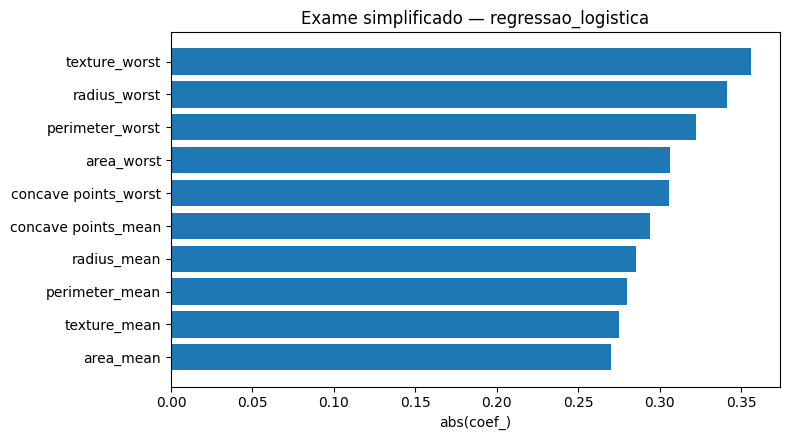

In [13]:
modelo_vencedor, hiper_vencedor, metricas_vencedor = modelos_otimizados[melhor_algoritmo]

print(f"Melhor modelo do GA: {melhor_algoritmo}")
print("Importância das medidas em cada modelo otimizado (top 5):\n")
for nome, (modelo_i, _, _) in modelos_otimizados.items():
    metodo_i, ranking_i = ga_utils.importancias_do_modelo(modelo_i, feature_names)
    print(f"{nome} ({metodo_i})")
    for item in ranking_i[:5]:
        print(f"  {item['feature']:24} {item['importancia']:.4f}")
    print()

exame_simplificado = ga_utils.persistir_exame_simplificado(
    algoritmo=melhor_algoritmo,
    modelo=modelo_vencedor,
    hiperparametros=hiper_vencedor,
    feature_names=feature_names,
)

print("10 medidas exportadas para a API e o Angular:")
for i, item in enumerate(exame_simplificado["features"], start=1):
    print(f"  {i:2}. {item['feature']:24} {item['importancia']:.4f}")
print("\nMétricas do exame simplificado no holdout:", exame_simplificado["metricas_holdout"])
print("Arquivo:", RESULTADOS_DIR / "feature_importances.json")

nomes = [item["feature"] for item in exame_simplificado["features"]][::-1]
pesos = [item["importancia"] for item in exame_simplificado["features"]][::-1]
plt.figure(figsize=(8, 4.5))
plt.barh(nomes, pesos)
plt.xlabel(exame_simplificado["metodo"])
plt.title(f"Exame simplificado — {exame_simplificado['algoritmo']}")
plt.tight_layout()
plt.show()


## Interpretação com LLM (Claude)

Até aqui o notebook está cheio de número: acurácia, recall, `area_worst`, probabilidade... Isso é ótimo pra gente comparar modelo, mas um médico não vai ler a tabela e sair entendendo o exame.

A ideia desta parte é simples: a gente pega o que o modelo já calculou e pede pro Claude escrever em português, como se fosse um colega explicando o resultado. Não é o Claude que diagnostica — ele só traduz o que o modelo já decidiu.

Mandamos dois pedidos:

1. **Laudo de um paciente** — o mesmo tipo de texto que a API e o front mostram: deu positivo ou negativo, qual a chance de ser maligno e por quê (tamanho, textura, formato).
2. **Relatório dos experimentos** — um resumo de qual modelo ganhou depois do GA e quais medidas do tumor mais pesaram.

O texto que a gente “ensina” o Claude a seguir (o prompt) está em `src/llm_utils.py`. Separar o papel dele dos números do paciente evita que ele invente exame ou fale em hiperparâmetro no laudo.

Para esta célula funcionar, a chave da Anthropic precisa estar no arquivo `.env`.

In [12]:
modelo_final, hiperparametros_final, metricas_final = modelos_otimizados[melhor_algoritmo]
y_pred_final = ga_utils.prever_modelo(melhor_algoritmo, modelo_final, X_test, hiperparametros_final)

idx = next((i for i in range(len(y_pred_final)) if int(y_pred_final[i]) == 1), 0)
predicao_texto = "Maligno" if int(y_pred_final[idx]) == 1 else "Benigno"
if hasattr(modelo_final, "predict_proba"):
    chance_doenca = float(modelo_final.predict_proba(X_test[idx : idx + 1])[0][1])
else:
    chance_doenca = float(np.clip(modelo_final.predict(X_test[idx : idx + 1])[0], 0, 1))

valores_originais = scaler.inverse_transform(X_test[idx : idx + 1])[0]
features_paciente = llm_utils.obter_features_importantes(
    modelo_final, feature_names, valores_originais
)
prompt_laudo = llm_utils.montar_prompt(
    predicao=predicao_texto,
    chance_doenca=chance_doenca,
    features_importantes=features_paciente,
    accuracy=metricas_final["accuracy"],
    recall=metricas_final["recall"],
    f1=metricas_final["f1"],
    contexto_ga=llm_utils.formatar_contexto_ga(melhor_algoritmo, hiperparametros_final),
)
prompt_relatorio = llm_utils.montar_prompt_relatorio(
    comparacao=comparacao_final,
    melhor_algoritmo=melhor_algoritmo,
    hiperparametros=hiperparametros_final,
    metricas=metricas_final,
    features_top=exame_simplificado["features"],
)

chave = llm_utils.carregar_chave_do_env()
if not chave:
    print("Preencha ANTHROPIC_API_KEY no .env na raiz do projeto para o Claude escrever os textos.")
else:
    laudo = llm_utils.gerar_explicacao(prompt_laudo, api_key=chave)
    relatorio = llm_utils.gerar_explicacao(
        prompt_relatorio,
        api_key=chave,
        system_prompt=llm_utils.SYSTEM_PROMPT_RELATORIO,
        max_tokens=700,
    )
    print("=== Laudo de um paciente (mesmo tipo da API) ===\n")
    print(laudo)
    print("\n=== Relatório dos experimentos do GA ===\n")
    print(relatorio)
    (RESULTADOS_DIR / "relatorio_llm.txt").write_text(
        "LAUDO\n\n" + laudo + "\n\nRELATÓRIO\n\n" + relatorio,
        encoding="utf-8",
    )


=== Laudo de um paciente (mesmo tipo da API) ===

**LAUDO DE TRIAGEM AUTOMÁTICA DE CÂNCER DE MAMA**

**Resultado: POSITIVO — Indica doença (tumor maligno)**

Nossa detecção automática indicou 100% de chance de o tumor ser maligno. Essa conclusão se baseia principalmente em três características: a textura extremamente alterada do tecido, o tamanho bastante aumentado (raio de 25,6 mm) e o perímetro irregular do tumor (165,3 mm). Esses achados em conjunto apontam para características típicas de malignidade.

É importante ressaltar que este é um resultado de triagem automática e não substitui o diagnóstico clínico e histopatológico definitivo. Recomenda-se prosseguir com investigação complementar conforme protocolos institucionais.

=== Relatório dos experimentos do GA ===

# Relatório do Experimento de Triagem Automática de Câncer de Mama

O modelo de **Regressão Logística otimizado** apresentou o melhor desempenho, alcançando acurácia de 99.1%, recall de 97.6% e F1 de 0.99. Comparado à v

## Avaliação das interpretações

Não tem uma nota automática do tipo “o laudo tirou 9,2”. A gente lê o que o Claude escreveu e vê se está honesto e útil.

No laudo: ele começou dizendo se deu positivo ou negativo? A porcentagem é a mesma que o modelo calculou? Ele fala do tumor (tamanho, textura, contorno) sem inventar outro exame? No final ele deixa claro que isso é uma triagem, não um diagnóstico médico?

No relatório: ele aponta o mesmo vencedor da tabela de cima? As medidas que ele cita são as que exportamos no exame simplificado?

Se alguma coisa escapar — um número inventado, um termo de machine learning no meio do laudo — o problema quase sempre está no que a gente pediu, em `src/llm_utils.py`. Aí a gente ajusta o prompt e roda de novo.

## Conclusão

- Os 3 algoritmos do notebook 01 foram otimizados via Algoritmo Genético, cada um com um espaço de genes adequado ao seu tipo de hiperparâmetro.
- 3 experimentos, cada um com uma configuração diferente do GA (população/mutação/gerações), cobrindo os 3 algoritmos.
- A tabela de comparação (`experiments/results/comparison_table.csv`) mostra o ganho (ou não) de cada modelo otimizado em relação ao baseline.
- As feature importances do vencedor vão para `feature_importances.json`; a API e o Angular montam o exame simplificado a partir desse arquivo.
- A LLM gera um laudo de paciente (igual à API) e um relatório dos experimentos. Os prompts estão em `src/llm_utils.py`.
